In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, END, START
from dotenv import load_dotenv

import os
import base64
from pathlib import Path

load_dotenv()

True

In [2]:

from openai import OpenAI
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))


In [3]:
class State(TypedDict):
    product_name: str
    basic_description: str
    features_benefits: str
    marketing_message: str
    image_url: str
    final_description: str


    

In [4]:
def generate_basic_description(state: State) -> State:
    product_name = state['product_name']
    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that generates product descriptions."},
            {"role": "user", "content": f"Generate a basic description for the product: {product_name}."}
        ]
    )
    basic_description = response.choices[0].message.content.strip()

    return {"basic_description":basic_description}


In [5]:
def add_features_benefits(state: State) -> State:
    basic_description = state['basic_description']

    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that adds features and benefits to product descriptions."},
            {"role": "user", "content": f"Based on the basic description: {basic_description}, list the features and benefits of the product."}
        ]
    )
    features_benefits = response.choices[0].message.content.strip()

    return {"features_benefits": features_benefits}





In [6]:
def create_image(state: State) -> State:
    prompt = (
        f"Professional product photo of {state['product_name']}. "
        f"Clean background, marketing style. "
        f"Features: {state['features_benefits'][:500]}"
    )


    # DALL·E 3 was retired in May 2026. GPT Image returns base64, not a hosted URL.
    response = client.images.generate(
        model="gpt-image-2",
        prompt=prompt,
        size="1024x1024",
        n=1,
    )
    
    image_b64 = response.data[0].b64_json
    images_dir = Path("images")
    images_dir.mkdir(exist_ok=True)

    image_path = images_dir / f"{state['product_name'].lower().replace(' ', '_')}.png"
    image_path.write_bytes(base64.b64decode(image_b64))

    image_url = f"data:image/png;base64,{image_b64}"
    return {"image_url": image_url}
    

In [7]:
def create_marketing_message(state: State) -> State:
    basic_description = state['basic_description']
    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that creates marketing messages for products."},
            {"role": "user", "content": f"Create a marketing message based on the features and benefits: {state['features_benefits']}."}
        ]
    )
    
    marketing_message = response.choices[0].message.content.strip()
    return {"marketing_message": marketing_message}

In [8]:
def polish_final_description(state: State) -> State:
    user_content = [
        {
            "type": "text",
            "text": (
                "Polish the following into one compelling final product description. "
                "Reference what you see in the product image (look, design, key visual features).\n\n"
                f"Basic Description: {state['basic_description']}\n"
                f"Marketing Message: {state['marketing_message']}"
            ),
        },
        {
            "type": "image_url",
            "image_url": {"url": state["image_url"]},
        },

    ]

    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {
                "role": "system",
                "content": "You are a helpful assistant that polishes product descriptions using text and images.",
            },
            {"role": "user", "content": user_content},
        ],
    )
    final_description = response.choices[0].message.content.strip()
    final_description += f"\n\n![{state['product_name']}]({state['image_url']})"
    return {"final_description": final_description}

In [9]:
def build_workflow():
    """Builds the state graph for the workflow."""
    workflow = StateGraph(State)
    workflow.add_node("generate_basic_description", generate_basic_description)
    workflow.add_node("add_features_benefits", add_features_benefits)
    workflow.add_node("create_image", create_image)
    workflow.add_node("create_marketing_message", create_marketing_message)
    workflow.add_node("polish_final_description", polish_final_description)

    workflow.add_edge(START, "generate_basic_description")
    workflow.add_edge("generate_basic_description", "add_features_benefits")
    workflow.add_edge("add_features_benefits", "create_image")
    workflow.add_edge("create_image", "create_marketing_message")
    workflow.add_edge("create_marketing_message", "polish_final_description")
    workflow.add_edge("polish_final_description", END)

    chain = workflow.compile()
    return chain



In [10]:
chain = build_workflow()

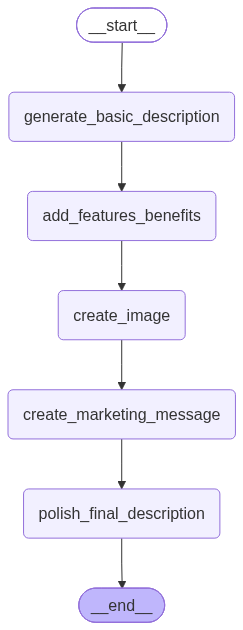

In [11]:

from IPython.display import Image, display

try:
    display(Image(chain.get_graph().draw_mermaid_png()))
except Exception as e:

    print(e)

In [12]:
product_name = "Apple Pencil"
state = State(
    product_name=product_name,
    basic_description="",
    features_benefits="",
    marketing_message="",
    image_url="",
    final_description="",
)

result = chain.invoke(state)

{'product_name': 'Apple Pencil',
 'basic_description': "The Apple Pencil is a powerful and versatile tool designed to enhance your creativity and productivity on your iPad. With its precision and responsiveness, you can sketch, write, draw, and annotate with ease. The Apple Pencil seamlessly integrates with various apps, providing a seamless and intuitive digital writing experience. Whether you're a student, artist, designer, or professional, the Apple Pencil is the perfect companion for unleashing your creativity and productivity.",
 'features_benefits': "Features and Benefits of the Apple Pencil:\n\n1. **Precision and Responsiveness**: The Apple Pencil offers unparalleled precision and responsiveness, allowing you to sketch, write, draw, and annotate with incredible accuracy. This ensures that your work is detailed and refined, just like using a traditional pen or pencil.\n\n2. **Seamless Integration with Apps**: The Apple Pencil seamlessly integrates with a variety of apps on your i
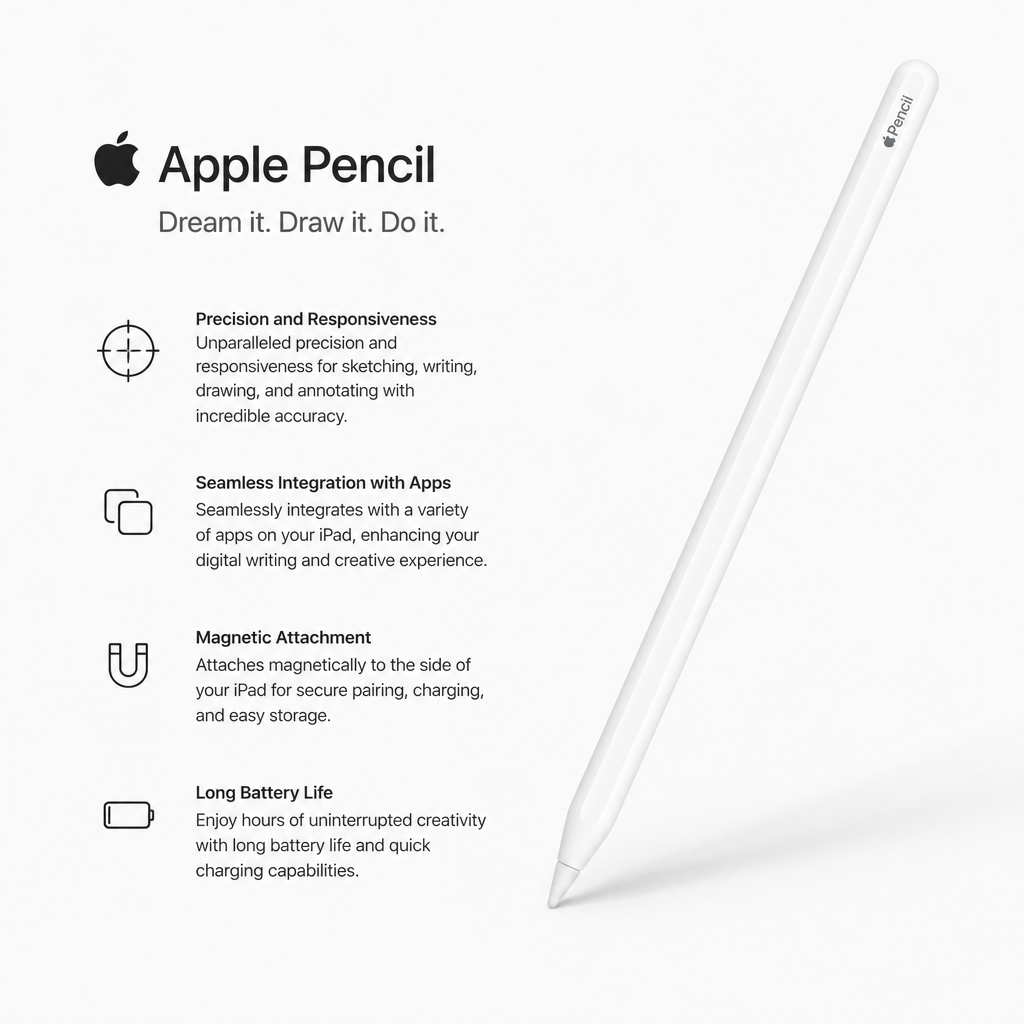
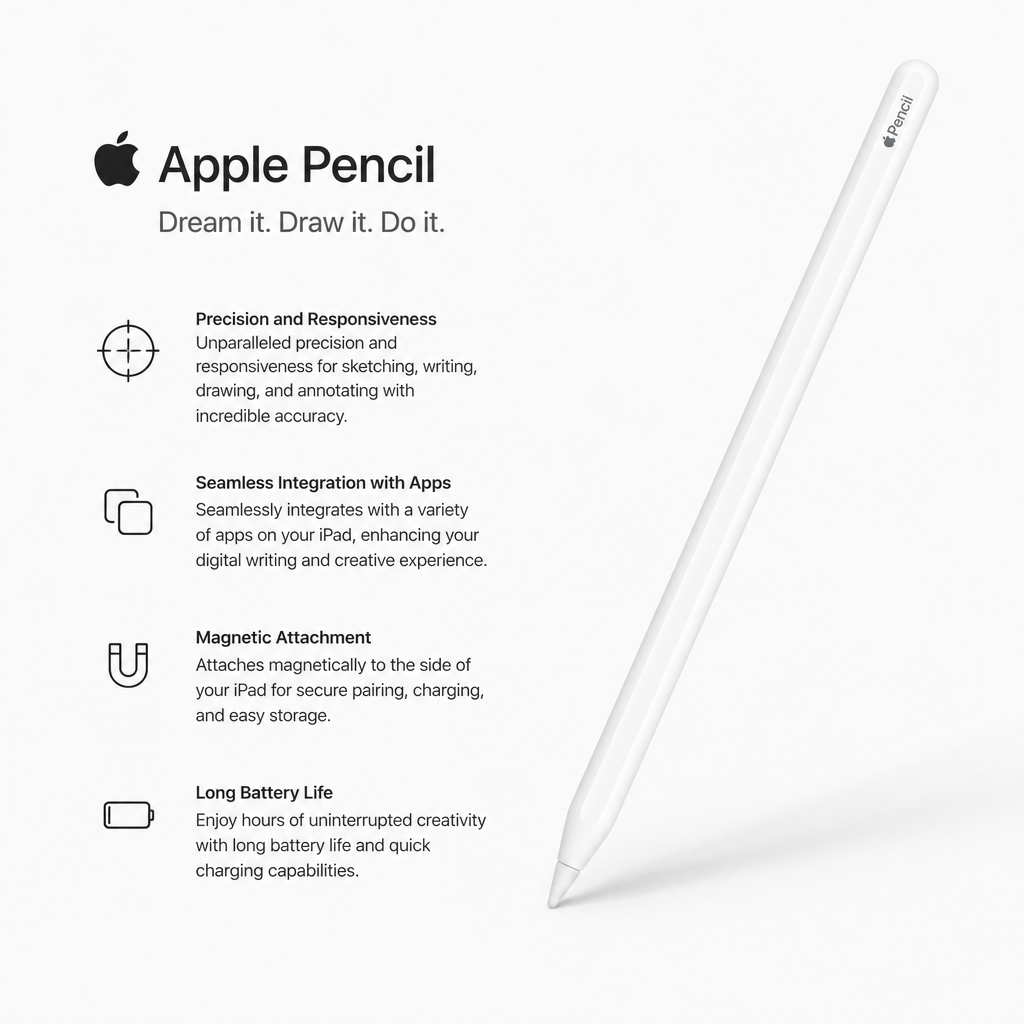

In [13]:
result